Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20


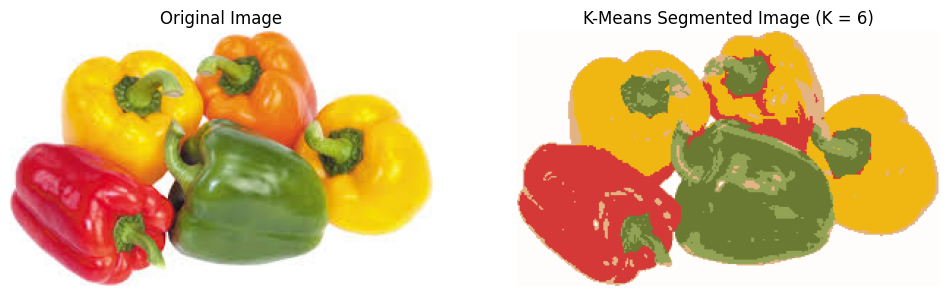

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import img_as_float

# Load an image 

try:
    img = plt.imread('peppers.jpeg')
except FileNotFoundError:
    print("File not found, using sample image instead.")
    img = data.astronaut() 

# Convert to double (float) for processing (0 to 1 range)
img = img_as_float(img)

# Get the size
rows, cols, ch = img.shape

# Reshape image into N x 3 matrix
pixels = img.reshape(-1, 3)

# Choose no. of clusters
K = 6  

# Initialize cluster centers randomly

rand_idx = np.random.choice(pixels.shape[0], K, replace=False)
centers = pixels[rand_idx, :]      # K initial centers (RGB values)

# To store cluster assignments
cluster_idx = np.zeros(pixels.shape[0])

# K-Means Iteration Loop
max_iters = 20

for iter_count in range(max_iters):
    print(f'Iteration {iter_count + 1}')

    # assingning pixel to the nearest cluster
    dists = np.sum((pixels[:, np.newaxis, :] - centers[np.newaxis, :, :]) ** 2, axis=2)
    
    # Assign pixel to closest cluster (min distance index)
    cluster_idx = np.argmin(dists, axis=1)

   
    # Update cluster centers
    
    new_centers = np.zeros((K, 3))
    
    for k in range(K):
        # Get all pixels belonging to cluster k
        cluster_pixels = pixels[cluster_idx == k]

        # Avoid empty clusters
        if len(cluster_pixels) > 0:
            new_centers[k, :] = np.mean(cluster_pixels, axis=0)
        else:
            new_centers[k, :] = centers[k, :]


    if np.all(np.abs(new_centers - centers) < 1e-5):
        print('Converged.')
        break

    centers = new_centers # Update centers


# Reconstruct segmented image using final cluster centers

segmented_pixels = np.zeros_like(pixels)

for k in range(K):
    segmented_pixels[cluster_idx == k] = centers[k]

segmented_img = segmented_pixels.reshape(rows, cols, 3)

# Display Results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_img)
plt.title(f'K-Means Segmented Image (K = {K})')
plt.axis('off')

plt.show()